In [ ]:
print("Trader Performance vs Market Sentiment Analysis")
print("Primetrade.ai Data Science Intern Assignment")
print("Submitted by: Saloni Saini")
print("Date: June 2026")

Trader Performance vs Market Sentiment Analysis
Primetrade.ai Data Science Intern Assignment
Submitted by: Saloni Saini
Date: June 2026


In [1]:
!pip install gdown

!gdown "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf" -O fear_greed.csv
!gdown "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs" -O trades.csv

Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed.csv
100% 90.8k/90.8k [00:00<00:00, 88.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trades.csv
100% 47.5M/47.5M [00:01<00:00, 40.2MB/s]


In [4]:
# Import pandas and load both datasets
import pandas as pd

sentiment = pd.read_csv('fear_greed.csv')
trades = pd.read_csv('trades.csv')

In [5]:
# Preview first 5 rows of both datasets
print(sentiment.head())
print("\n")
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:5

In [6]:
# Check shape, missing values and duplicates
print("Fear & Greed Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

print("\nMissing Values in Sentiment Dataset:")
print(sentiment.isnull().sum())

print("\nMissing Values in Trader Dataset:")
print(trades.isnull().sum())

print("\nDuplicate Rows in Sentiment Dataset:", sentiment.duplicated().sum())
print("Duplicate Rows in Trader Dataset:", trades.duplicated().sum())

Fear & Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)

Missing Values in Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trader Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows in Sentiment Dataset: 0
Duplicate Rows in Trader Dataset: 0


In [7]:
# Sentiment dataset date conversion
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trader dataset date conversion
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create a date-only column
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [8]:
# Verify date format looks correct in both datasets
print(sentiment[['date']].head())
print(trades[['date']].head())

        date
0 2018-02-01
1 2018-02-02
2 2018-02-03
3 2018-02-04
4 2018-02-05
        date
0 2024-12-02
1 2024-12-02
2 2024-12-02
3 2024-12-02
4 2024-12-02


In [9]:
# Check date ranges to see overlap between both datasets
print("Sentiment Date Range:")
print(sentiment['date'].min())
print(sentiment['date'].max())

print("\nTrader Date Range:")
print(trades['date'].min())
print(trades['date'].max())

Sentiment Date Range:
2018-02-01 00:00:00
2025-05-02 00:00:00

Trader Date Range:
2023-05-01 00:00:00
2025-05-01 00:00:00


In [10]:
# Merge both datasets on date column
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

print(merged.shape)
merged.head()

(211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [11]:
# Calculate total PnL per day
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()

print(daily_pnl.head())

        date  Closed PnL
0 2023-05-01    0.000000
1 2023-12-05    0.000000
2 2023-12-14 -205.434737
3 2023-12-15  -24.632034
4 2023-12-16    0.000000


In [12]:
# Count number of trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='Number_of_Trades')

print(trades_per_day.head())

        date  Number_of_Trades
0 2023-05-01                 3
1 2023-12-05                 9
2 2023-12-14                11
3 2023-12-15                 2
4 2023-12-16                 3


In [13]:
# Calculate average trade size (in USD) per day
avg_trade_size = merged.groupby('date')['Size USD'].mean().reset_index()

print(avg_trade_size.head())

        date      Size USD
0 2023-05-01    159.000000
1 2023-12-05   5556.203333
2 2023-12-14  10291.213636
3 2023-12-15   5304.975000
4 2023-12-16   5116.256667


In [14]:
# Check unique trade directions (Long/Short)
print(merged['Direction'].value_counts())

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [15]:
# Calculate overall Long vs Short ratio
long_short = merged['Direction'].value_counts()

long_trades = long_short['Open Long']
short_trades = long_short['Open Short']

ratio = long_trades / short_trades

print("Long Trades:", long_trades)
print("Short Trades:", short_trades)
print("Long/Short Ratio:", round(ratio, 2))

Long Trades: 49895
Short Trades: 39741
Long/Short Ratio: 1.26


In [16]:
# Average PnL for each sentiment category
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_by_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


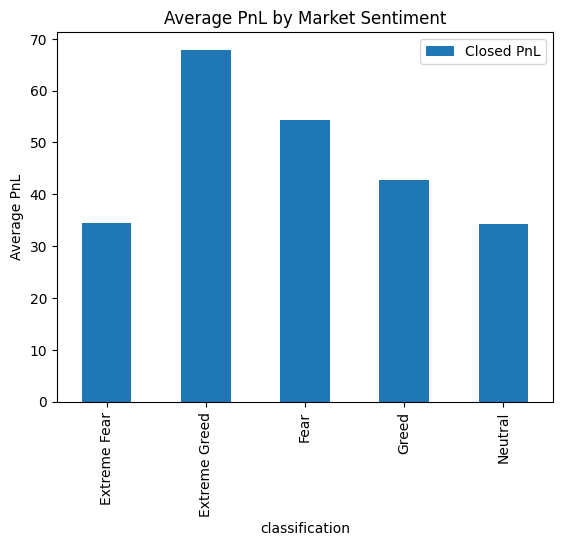

In [17]:
# Chart 1 - Avg PnL by Sentiment
import matplotlib.pyplot as plt

pnl_by_sentiment.plot(
    x='classification',
    y='Closed PnL',
    kind='bar'
)

plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.show()

In [18]:
# Count total trades on each sentiment day
trade_freq = merged.groupby('classification').size().reset_index(name='Number_of_Trades')

print(trade_freq)

  classification  Number_of_Trades
0   Extreme Fear             21400
1  Extreme Greed             39992
2           Fear             61837
3          Greed             50303
4        Neutral             37686


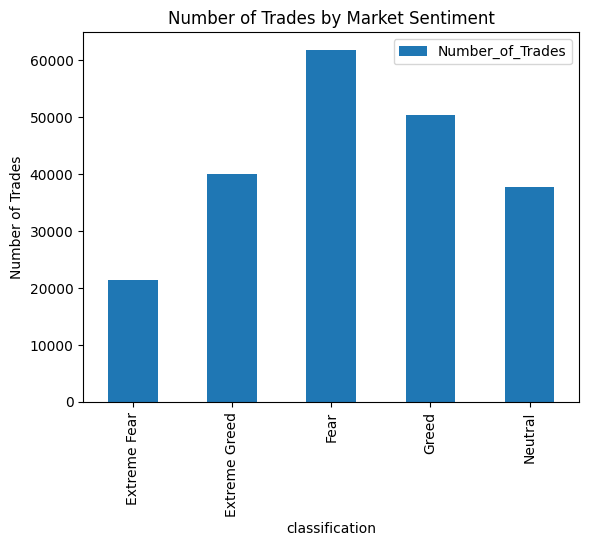

In [19]:
# Chart 2 - Trade Frequency by Sentiment
trade_freq.plot(
    x='classification',
    y='Number_of_Trades',
    kind='bar'
)

plt.title('Number of Trades by Market Sentiment')
plt.ylabel('Number of Trades')
plt.show()

In [20]:
# Average position size (USD) on each sentiment dayV
position_size = merged.groupby('classification')['Size USD'].mean().reset_index()

print(position_size)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


In [21]:
# Count total trades per trader to identify frequent vs infrequent
trader_counts = merged.groupby('Account').size().reset_index(name='Trade_Count')

print(trader_counts.head())
print("\nTotal Traders:", trader_counts.shape[0])

                                      Account  Trade_Count
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280
2  0x271b280974205ca63b716753467d5a371de622ab         3809
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239

Total Traders: 32


In [22]:
# Segment traders as Frequent or Infrequent based on median trade count
median_trades = trader_counts['Trade_Count'].median()

trader_counts['Segment'] = trader_counts['Trade_Count'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

print(trader_counts['Segment'].value_counts())

Segment
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64


In [23]:
# Calculate total PnL per trader
trader_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()

print(trader_pnl.head())

                                      Account    Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05


In [24]:
# Segment traders as Winner or Non-Winner based on total PnL
trader_pnl['Segment'] = trader_pnl['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Non-Winner'
)

print(trader_pnl['Segment'].value_counts())

Segment
Winner        29
Non-Winner     3
Name: count, dtype: int64


In [25]:
# Summary table of key findings
summary = pd.DataFrame({
    'Insight': [
        'Highest Average PnL',
        'Most Active Sentiment',
        'Largest Position Size'
    ],
    'Result': [
        'Extreme Greed',
        'Fear',
        'Fear'
    ]
})

print(summary)

                 Insight         Result
0    Highest Average PnL  Extreme Greed
1  Most Active Sentiment           Fear
2  Largest Position Size           Fear
